In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("heart.csv")
print(df.head(10))
print(df.shape)
print(df.info())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   
5   39   M           NAP        120          339          0     Normal    170   
6   45   F           ATA        130          237          0     Normal    170   
7   54   M           ATA        110          208          0     Normal    142   
8   37   M           ASY        140          207          0     Normal    130   
9   48   F           ATA        120          284          0     Normal    120   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1     

In [8]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [9]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Remove duplicate rows
df = df.drop_duplicates()

# Print the new shape of the dataset
print("New shape of the dataset:", df.shape)

Number of duplicate rows: 0
New shape of the dataset: (918, 12)


In [19]:
chol = df["Cholesterol"]==0
print(chol.sum())
rest_bp = df["RestingBP"]==0
print(rest_bp.sum())

172
1


In [ ]:
print("Statistical Summary Before Cleaning:\n")
print(df[["Cholesterol", "RestingBP"]].describe())

chol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean)

bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()
df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)

print("\nStatistical Summary After Cleaning:\n")
print(df[["Cholesterol", "RestingBP"]].describe())


Statistical Summary Before Cleaning:

       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.635389  132.540894
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.635389  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000
Zeros in Cholesterol: 0
Zeros in RestingBP: 0

Statistical Summary After Cleaning:

       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.635389  132.540894
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.635389  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


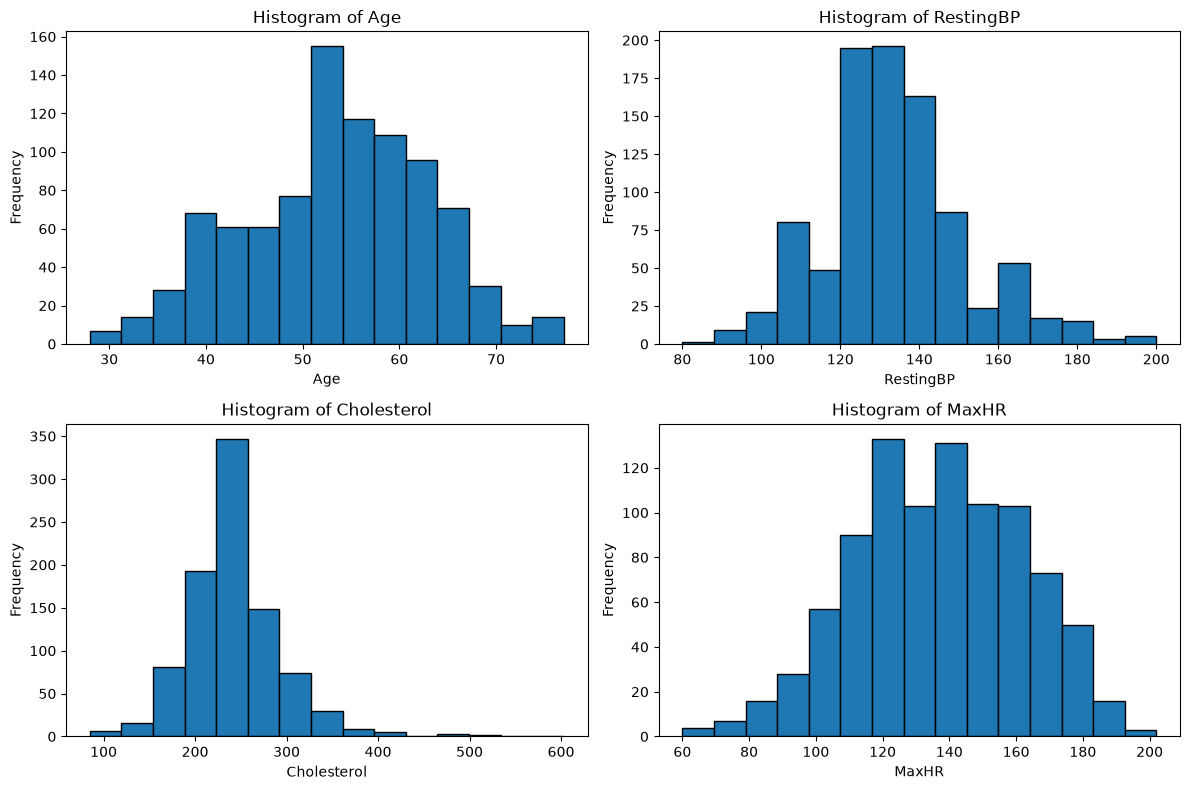

In [33]:
chol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()

df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean)
df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)

# Function to plot histograms
def plot_histograms(data):
    columns = ["Age", "RestingBP", "Cholesterol", "MaxHR"]

    plt.figure(figsize=(12, 8))

    for i, col in enumerate(columns, 1):
        plt.subplot(2, 2, i)
        plt.hist(data[col], bins=15, edgecolor='black')
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Call the function
plot_histograms(df)

In [40]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['str']).columns

# Print the columns
print("Numerical Columns:")
print(list(numerical_columns))

print("\nCategorical Columns:")
print(list(categorical_columns))

Numerical Columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']

Categorical Columns:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [41]:
df_encoded = pd.get_dummies(df)

# Print the shape of the encoded dataframe
print("Shape of Encoded DataFrame:", df_encoded.shape)

# Print the first 5 rows
print("\nFirst 5 Rows of Encoded DataFrame:")
print(df_encoded.head())

Shape of Encoded DataFrame: (918, 21)

First 5 Rows of Encoded DataFrame:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             Fals

In [43]:
# Data Cleaning
chol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()

df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean)
df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['str']).columns

# Perform One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_columns)

# Print the final shape
print("Final Shape of df_encoded:")
print(df_encoded.shape)

# Print all column names
print("\nColumn Names in df_encoded:")
print(df_encoded.columns.tolist())

Final Shape of df_encoded:
(918, 21)

Column Names in df_encoded:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']


In [46]:
print("SUMMARY:")
print("1. The `Cholesterol` column contained invalid values where the cholesterol level was `0`.")
print("2. Invalid values can reduce the accuracy of data analysis and machine learning models.")
print("3. One-Hot Encoding converts categorical (text) data into numerical columns.")
print("4. Most numerical columns contained valid values except `Cholesterol` and `RestingBP`.")

SUMMARY:
1. The `Cholesterol` column contained invalid values where the cholesterol level was `0`.
2. Invalid values can reduce the accuracy of data analysis and machine learning models.
3. One-Hot Encoding converts categorical (text) data into numerical columns.
4. Most numerical columns contained valid values except `Cholesterol` and `RestingBP`.
